     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 95.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=ca7a899e886cc3f0fa3f77d1ee68c8879368f7e968383704184ba5778daefd8d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam

===== DENSENET121 =====
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 223MB/s]


Backbone unfreeze...
Early stopping.

===== RESNET50 =====
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 228MB/s]


Backbone unfreeze...
Early stopping.

===== EFFICIENTNET_B0 =====
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 209MB/s]


Backbone unfreeze...
Early stopping.
             Model    Val F1   Test F1  Test ROC-AUC
2  efficientnet_b0  0.957641  0.979063      0.996086
0      densenet121  0.985880  0.969993      0.993995
1         resnet50  0.972364  0.962539      0.997042

=== SOFT VOTING ===
F1: 0.9790632685603091
ROC-AUC: 0.9996408432777737


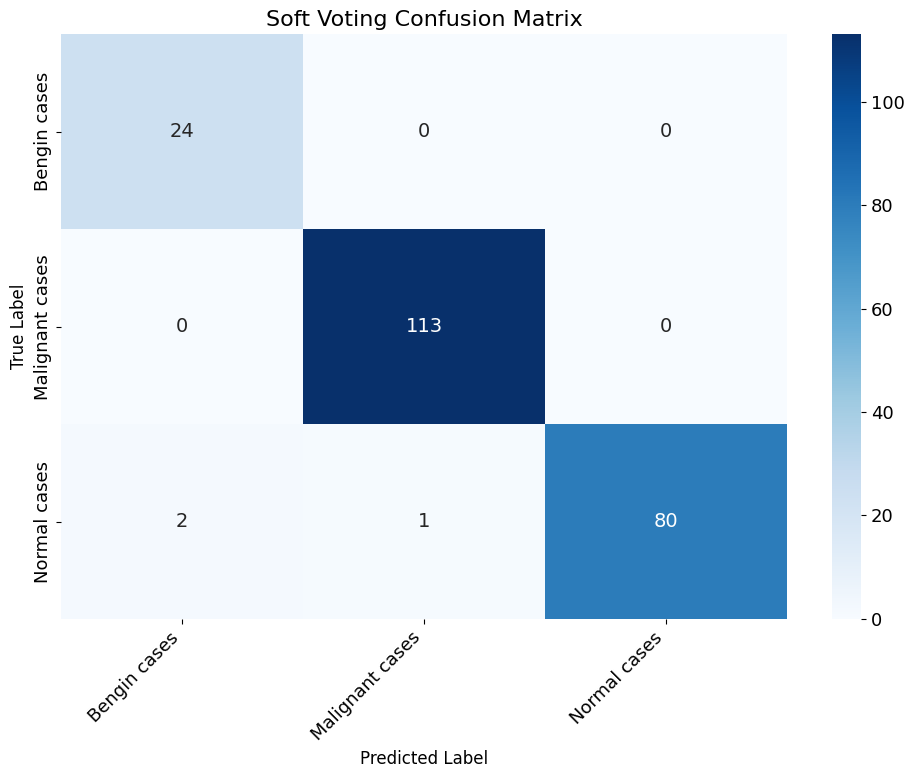

                 precision    recall  f1-score   support

   Bengin cases       0.92      1.00      0.96        24
Malignant cases       0.99      1.00      1.00       113
   Normal cases       1.00      0.96      0.98        83

       accuracy                           0.99       220
      macro avg       0.97      0.99      0.98       220
   weighted avg       0.99      0.99      0.99       220



In [1]:
# =========================
# 0. IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
!pip install grad-cam
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
!pip install grad-cam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "svg.fonttype": "none"   # Fontlar metin olarak kalsın (çok önemli!)
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

# =========================
# 1. DATA PREPARATION
# =========================
BASE_DIR = "/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset"

class_map = {
    "Bengin cases": 0,
    "Malignant cases": 1,
    "Normal cases": 2
}

filepaths, labels = [], []

for folder, label in class_map.items():
    folder_path = os.path.join(BASE_DIR, folder)
    for f in os.listdir(folder_path):
        filepaths.append(os.path.join(folder_path, f))
        labels.append(label)

df = pd.DataFrame({"path": filepaths, "label": labels})

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df["label"], random_state=42
)

# =========================
# 2. DATASET CLASS
# =========================
class LungDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "path"]).convert("RGB")
        label = self.df.loc[idx, "label"]
        if self.transform:
            img = self.transform(img)
        return img, label

train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

BATCH_SIZE = 16

train_loader = DataLoader(LungDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LungDataset(val_df, val_test_tfms), batch_size=BATCH_SIZE)
test_loader  = DataLoader(LungDataset(test_df, val_test_tfms), batch_size=BATCH_SIZE)

# =========================
# 3. CLASS WEIGHTS
# =========================
class_counts = train_df["label"].value_counts().sort_index()
weights = 1.0 / class_counts
weights = weights / weights.sum()
class_weights = torch.tensor(weights.values, dtype=torch.float).to(DEVICE)

# =========================
# 4. TRAIN & EVAL FUNCTIONS
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds, targets = 0, [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        optimizer.step()

        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(y.cpu().numpy())

    return (
        total_loss / len(loader),
        f1_score(targets, preds, average="macro"),
        accuracy_score(targets, preds)
    )


def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, preds, probs, targets = 0, [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds.extend(out.argmax(1).cpu().numpy())
            probs.extend(torch.softmax(out,1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    return (
        total_loss / len(loader),
        f1_score(targets, preds, average="macro"),
        accuracy_score(targets, preds),
        np.array(probs),
        np.array(targets)
    )

# =========================
# 5. MODEL TRAINING
# =========================
model_names = ["densenet121", "resnet50", "efficientnet_b0"]
all_histories = {}
results_list = []

for m_name in model_names:
    print(f"\n===== {m_name.upper()} =====")

    if m_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, 3)

    elif m_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, 3)

    elif m_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

    model = model.to(DEVICE)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    if m_name == "densenet121":
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif m_name == "resnet50":
        for param in model.fc.parameters():
            param.requires_grad = True
    else:
        for param in model.classifier.parameters():
            param.requires_grad = True

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=3e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    history = {"train_loss":[], "val_loss":[],
               "train_acc":[], "val_acc":[],
               "train_f1":[], "val_f1":[]}

    best_f1 = 0
    patience = 7
    counter = 0
    save_path = f"best_{m_name}.pth"

    for epoch in range(50):

        if epoch == 5:
            print("Backbone unfreeze...")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        tr_loss, tr_f1, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_f1, val_acc, val_probs, val_targets = eval_one_epoch(model, val_loader, criterion)

        scheduler.step(val_f1)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping.")
            break

    all_histories[m_name] = history

    model.load_state_dict(torch.load(save_path))
    _, test_f1, _, y_prob, y_true = eval_one_epoch(model, test_loader, criterion)

    roc_auc = roc_auc_score(
        torch.nn.functional.one_hot(torch.tensor(y_true), num_classes=3),
        y_prob,
        multi_class="ovr"
    )

    results_list.append({
        "Model": m_name,
        "Val F1": best_f1,
        "Test F1": test_f1,
        "Test ROC-AUC": roc_auc
    })

# =========================
# 6. RESULTS TABLE
# =========================
comparison_df = pd.DataFrame(results_list)
print(comparison_df.sort_values("Test F1", ascending=False))

# =========================
# 7. SOFT VOTING ENSEMBLE
# =========================
loaded_models = {}
for m_name in model_names:
    if m_name == "densenet121":
        model = models.densenet121()
        model.classifier = nn.Linear(model.classifier.in_features, 3)
    elif m_name == "resnet50":
        model = models.resnet50()
        model.fc = nn.Linear(model.fc.in_features, 3)
    else:
        model = models.efficientnet_b0()
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

    model.load_state_dict(torch.load(f"best_{m_name}.pth"))
    model = model.to(DEVICE)
    model.eval()
    loaded_models[m_name] = model

def soft_voting(models_dict, loader):
    all_probs = []
    y_true = []

    for model in models_dict.values():
        _, _, _, probs, targets = eval_one_epoch(model, loader, criterion)
        all_probs.append(probs)
        y_true = targets

    avg_probs = np.mean(all_probs, axis=0)
    preds = np.argmax(avg_probs, axis=1)

    return preds, avg_probs, y_true

voting_preds, voting_probs, y_true = soft_voting(loaded_models, test_loader)

print("\n=== SOFT VOTING ===")
print("F1:", f1_score(y_true, voting_preds, average="macro"))
print("ROC-AUC:", roc_auc_score(
    torch.nn.functional.one_hot(torch.tensor(y_true), num_classes=3),
    voting_probs,
    multi_class="ovr"
))

# =========================
# 8. CONFUSION MATRIX
# =========================
# =========================
# 8. CONFUSION MATRIX (GÜNCELLENDİ)
# =========================
plt.figure(figsize=(10, 8)) # Görsel boyutunu biraz büyütmek detayları netleştirir

cm = confusion_matrix(y_true, voting_preds)

# cmap="Blues" ile mavi tonlarını aktifleştiriyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_map.keys(),
            yticklabels=class_map.keys())

plt.title("Soft Voting Confusion Matrix", fontsize=16)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)

# X ekseni etiketlerini 45 derece döndürerek hizalıyoruz
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Etiketlerin kesilmesini önler
plt.show()

print(classification_report(y_true, voting_preds, target_names=list(class_map.keys())))

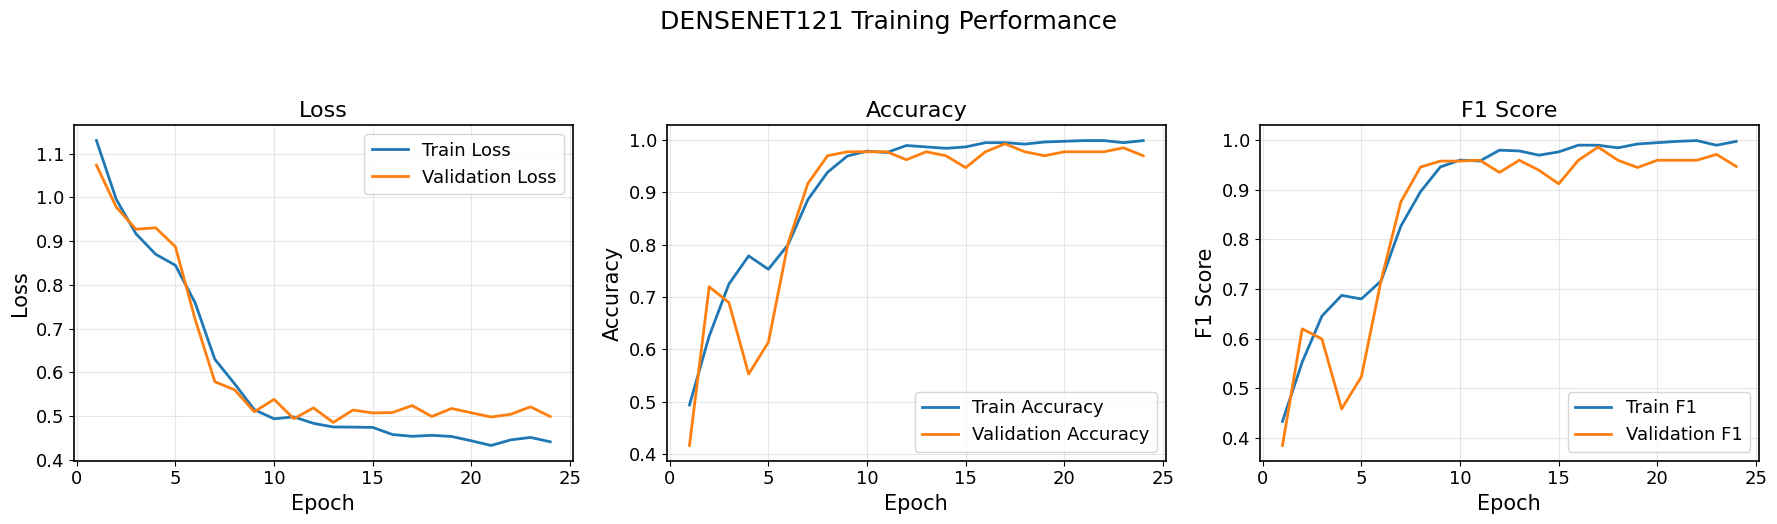

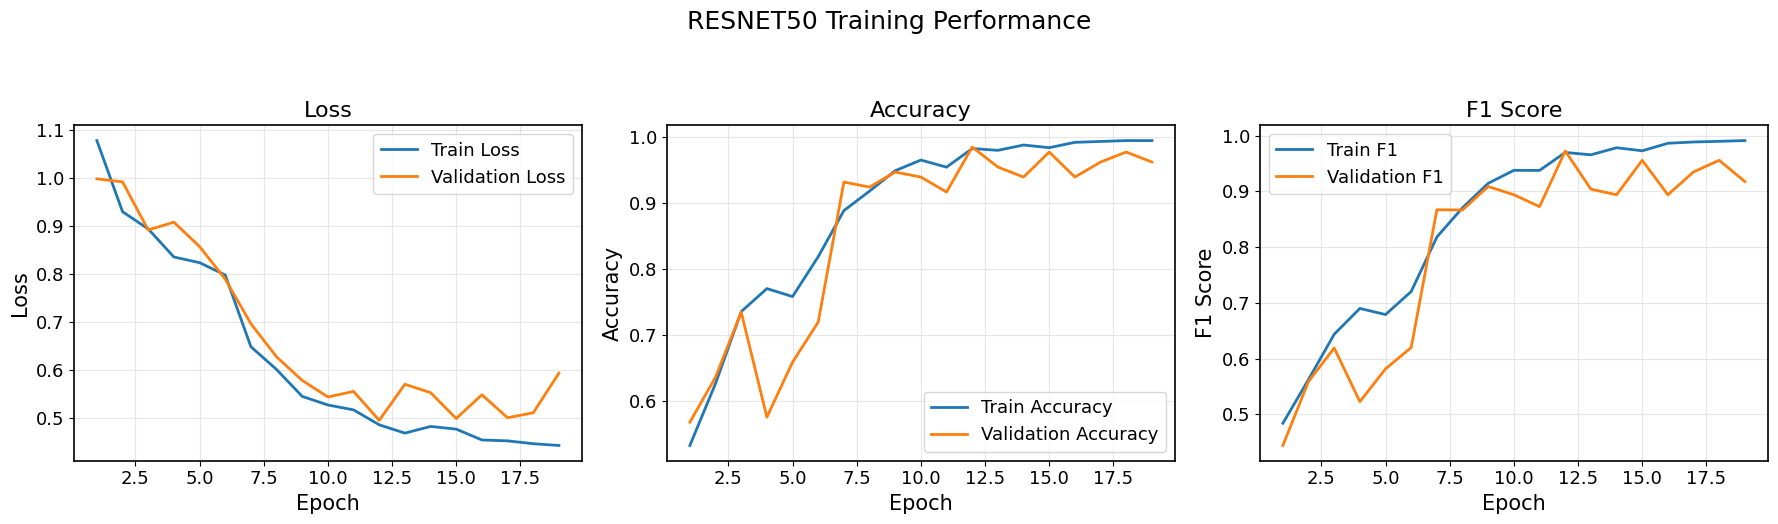

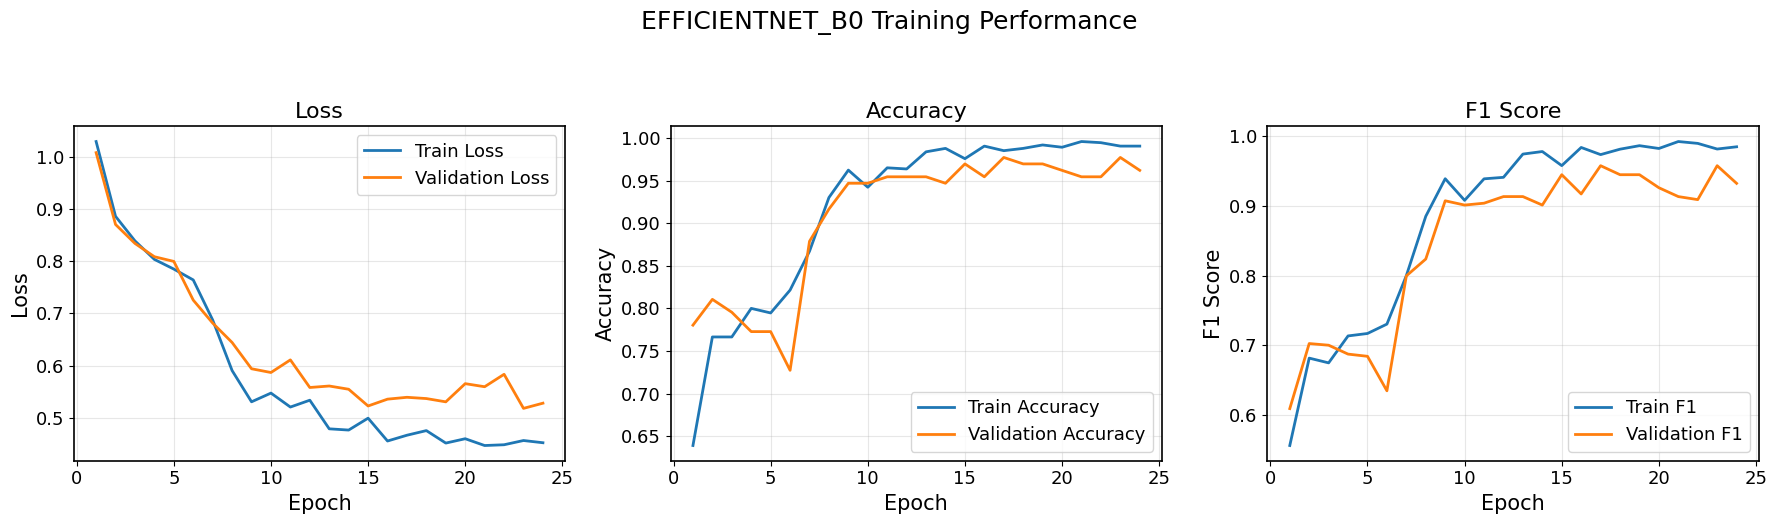

In [2]:
for model_name, history in all_histories.items():

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---- LOSS ----
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Validation Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ---- ACCURACY ----
    axes[1].plot(epochs, history["train_acc"], label="Train Accuracy")
    axes[1].plot(epochs, history["val_acc"], label="Validation Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # ---- F1 ----
    axes[2].plot(epochs, history["train_f1"], label="Train F1")
    axes[2].plot(epochs, history["val_f1"], label="Validation F1")
    axes[2].set_title("F1 Score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1 Score")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    fig.suptitle(f"{model_name.upper()} Training Performance", y=1.05)

    plt.tight_layout()

    # ✅ SVG olarak kaydet
    plt.savefig(f"{model_name}_training_curves.svg", format="svg", bbox_inches="tight")

    plt.show()

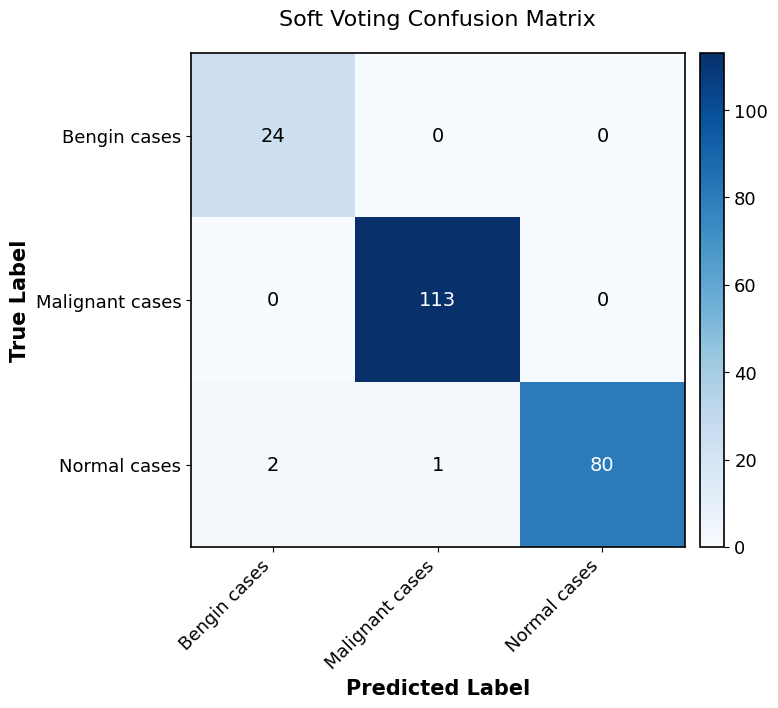

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from mpl_toolkits.axes_grid1 import make_axes_locatable # Eklenen import

# Veriler (Örnek amaçlı korunmuştur)
cm = confusion_matrix(y_true, voting_preds)
class_names = list(class_map.keys())

fig, ax = plt.subplots(figsize=(8, 8)) # Okunabilirlik için biraz büyütebilirsin
im = ax.imshow(cm, cmap="Blues")

# --- Renk Çubuğunu Boyuta Sabitleme ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15) # Sağda %5 kalınlığında bir alan açar
fig.colorbar(im, cax=cax)
# --------------------------------------

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted Label", fontweight='bold')
ax.set_ylabel("True Label", fontweight='bold')
ax.set_title("Soft Voting Confusion Matrix", pad=20)

# Hücre içi sayılar
for i in range(len(class_names)):
    for j in range(len(class_names)):
        # Sayının rengini arka plana göre ayarla (koyu mavi üstünde beyaz sayı)
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color=color, fontsize=14)

plt.tight_layout()
plt.savefig("soft_voting_confusion_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

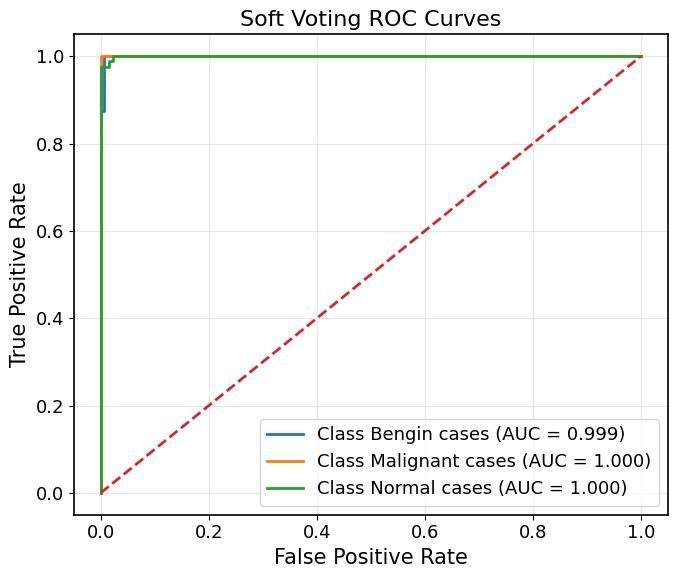

In [4]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])

fig = plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], voting_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Soft Voting ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("soft_voting_roc.svg", format="svg", bbox_inches="tight")
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Helper: unnormalize images back to viewable format
def unnormalize_img(tensor):
    img = tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

# Inverse class map (0 -> 'Bengin cases' etc.)
inv_class_map = {v: k for k, v in class_map.items()}

# Updated: Limit dynamic sample collection to 2 of each
correct_samples = []
incorrect_samples = []

m_dense = loaded_models["densenet121"]
m_res = loaded_models["resnet50"]
m_eff = loaded_models["efficientnet_b0"]

m_dense.eval()
m_res.eval()
m_eff.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        
        # Soft voting probabilities (equal weight average)
        out_dense = F.softmax(m_dense(x), dim=1)
        out_res = F.softmax(m_res(x), dim=1)
        out_eff = F.softmax(m_eff(x), dim=1)
        
        combined = (out_dense + out_res + out_eff) / 3.0
        preds = combined.argmax(1).cpu().numpy()
        labels_np = y.numpy()
        
        for i in range(len(labels_np)):
            is_correct = (preds[i] == labels_np[i])
            
            sample = {
                'tensor': x[i].unsqueeze(0),
                'image': unnormalize_img(x[i]),
                'true_label': inv_class_map[labels_np[i]],
                'pred_label': inv_class_map[preds[i]],
                'true_idx': labels_np[i]
            }
            
            # Updated to collect only 2 correct samples
            if is_correct and len(correct_samples) < 2:
                correct_samples.append(sample)
            # Collect up to 2 incorrect samples
            elif not is_correct and len(incorrect_samples) < 2:
                incorrect_samples.append(sample)

        # Break early if we have both
        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

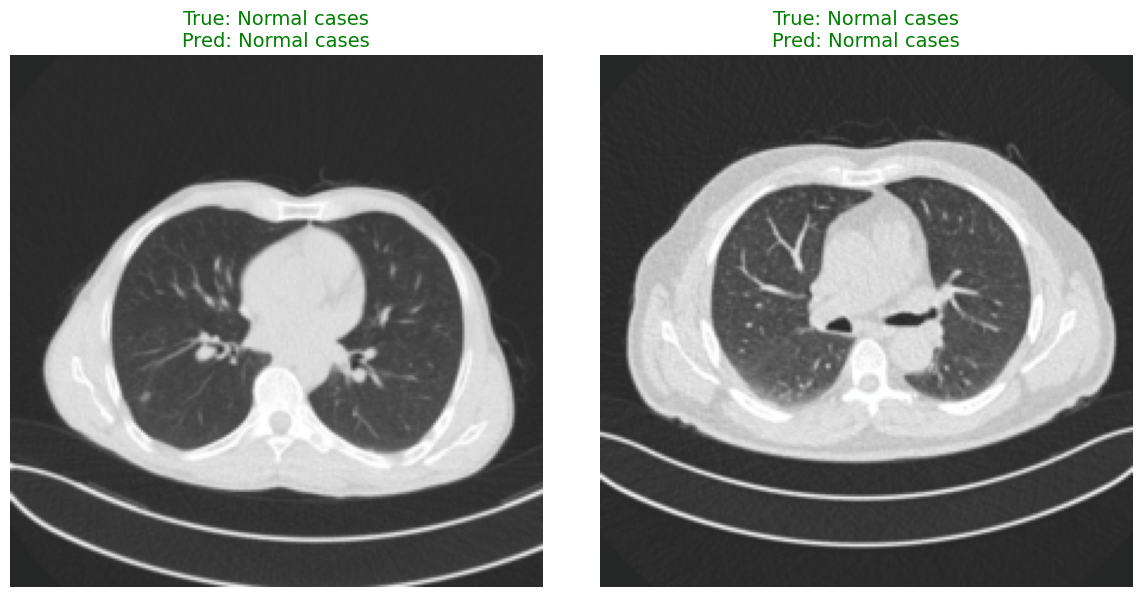

In [6]:
# =========================================
# VISUALIZATION 1: CORRECT PREDICTIONS (TOP 2 SAMPLES)
# =========================================
# subplots(1, 2) creates two columns side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Limit to 2 samples visually if somehow we have more
for i, sample in enumerate(correct_samples[:2]):
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"True: {sample['true_label']}\nPred: {sample['pred_label']}", color="green", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("correct_predictions_2samples.svg", format="svg", bbox_inches="tight")
plt.show()

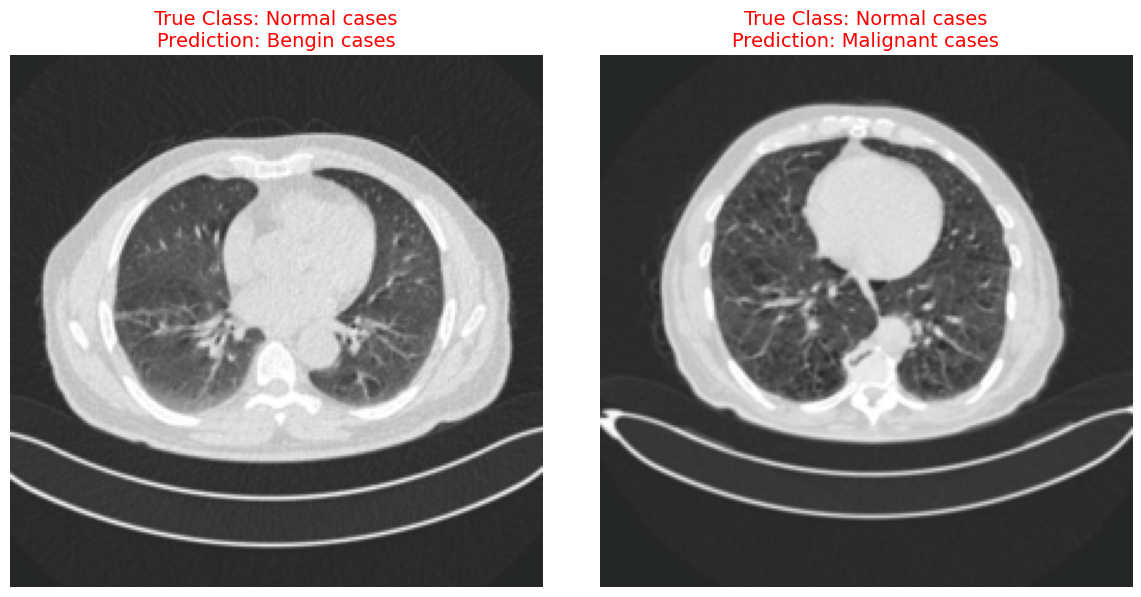

In [7]:
# =========================================
# VISUALIZATION 2: INCORRECT PREDICTIONS (TOP 2 SAMPLES)
# =========================================
num_incorrect = len(incorrect_samples)

if num_incorrect == 0:
    print("Excellent! Your ensemble model made zero errors on the unseen 'test_loader' data.")
else:
    # Dynamic subplot handling based on number of errors found (now capped at 2)
    fig, axes = plt.subplots(1, num_incorrect, figsize=(6 * num_incorrect, 6))
    
    # Handle the 'numpy.ndarray object not subscriptable' error if only 1 image exists
    if num_incorrect == 1:
        axes = [axes]
        

    for i, sample in enumerate(incorrect_samples[:2]):
        axes[i].imshow(sample['image'])
        axes[i].set_title(f"True Class: {sample['true_label']}\nPrediction: {sample['pred_label']}", color="red", fontsize=14)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("incorrect_predictions_2samples.svg", format="svg", bbox_inches="tight")
    plt.show()

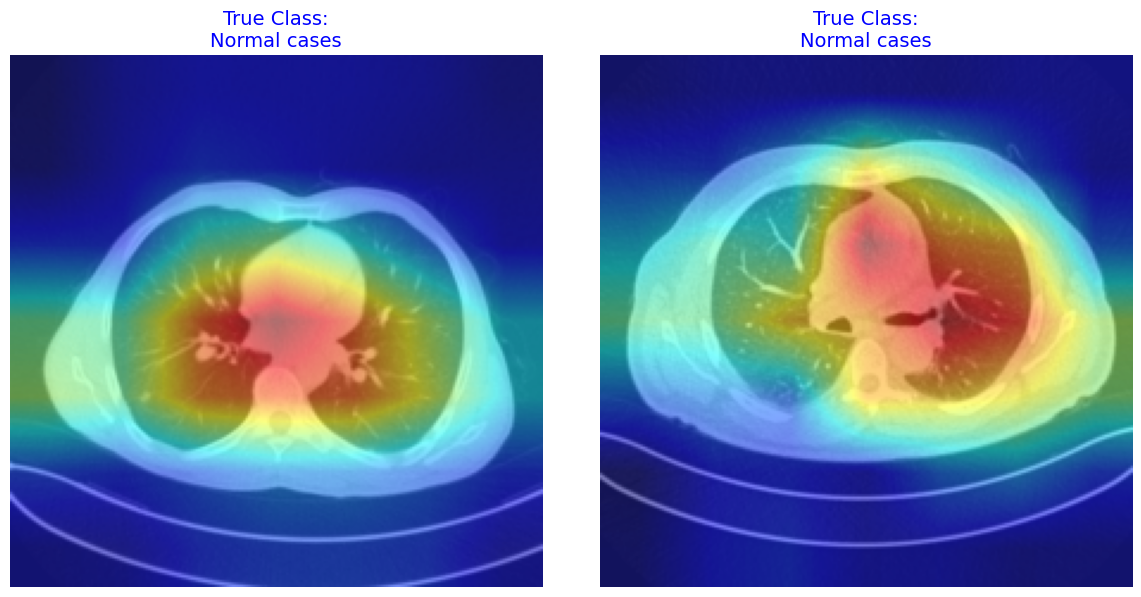

In [8]:
# =========================================
# VISUALIZATION 3: GRAD-CAM FOR CORRECT PREDICTIONS (TOP 2 SAMPLES)
# =========================================
# We use EfficientNet-b0's last convolutional layer for Grad-CAM
target_layers = [m_eff.features[-1]]
cam = GradCAM(model=m_eff, target_layers=target_layers)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, sample in enumerate(correct_samples[:2]):
    input_tensor = sample['tensor']
    target_class_idx = sample['true_idx']
    
    # Generate heatmap for the true class
    targets = [ClassifierOutputTarget(target_class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Overlay heatmap on the original image
    cam_image = show_cam_on_image(sample['image'], grayscale_cam, use_rgb=True)
    
    axes[i].imshow(cam_image)
    axes[i].set_title(f"True Class:\n{sample['true_label']}", color="blue", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("gradcam_correct_predictions_2samples.svg", format="svg", bbox_inches="tight")
plt.show()

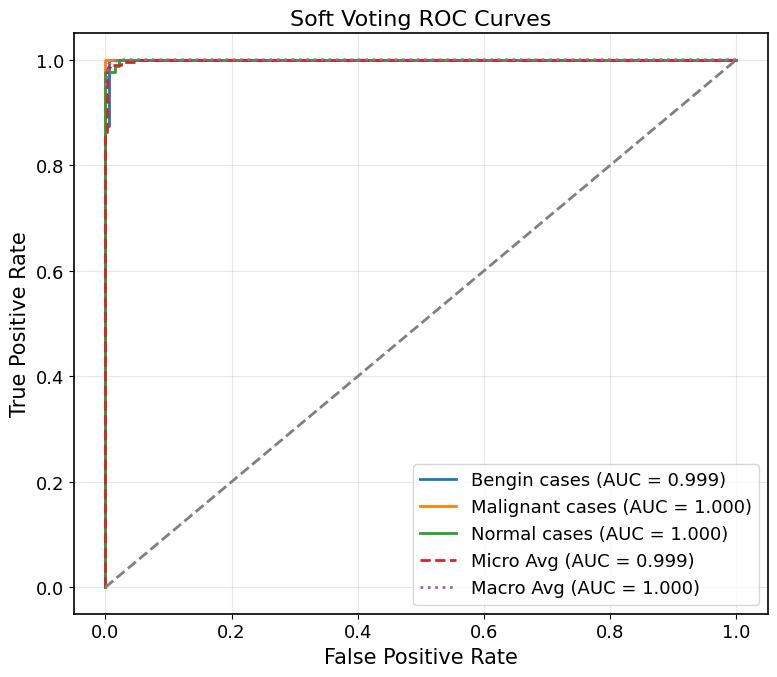


--- DEBUG ---
Bengin cases AUC: 0.9993622448979592
Malignant cases AUC: 1.0
Normal cases AUC: 0.9995602849353619
Micro AUC: 0.9993285123966942
Macro AUC: 0.9997808622393641

Probability range:
Min prob: 0.000735278
Max prob: 0.9970371

Sample probs (ilk 5):
[[0.13838656 0.15757085 0.7040426 ]
 [0.10639449 0.01505983 0.8785457 ]
 [0.12896779 0.79130656 0.07972557]
 [0.13458984 0.02147    0.8439401 ]
 [0.10852268 0.8596297  0.03184756]]


In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. BINARIZE LABELS
# =========================
n_classes = 3
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# =========================
# 2. ROC HESAPLAMA
# =========================
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], voting_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# =========================
# 3. MICRO AVERAGE
# =========================
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    voting_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# =========================
# 4. MACRO AVERAGE
# =========================
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# =========================
# 5. PLOT
# =========================
plt.figure(figsize=(8, 7))

# Class ROC
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Micro & Macro
plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"Micro Avg (AUC = {roc_auc['micro']:.3f})"
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    linestyle=":",
    label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})"
)

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Soft Voting ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("soft_voting_roc_full.svg", format="svg", bbox_inches="tight")
plt.show()

# =========================
# 6. DEBUG (ÇOK ÖNEMLİ)
# =========================
print("\n--- DEBUG ---")
for i in range(n_classes):
    print(f"{class_names[i]} AUC:", roc_auc[i])

print("Micro AUC:", roc_auc["micro"])
print("Macro AUC:", roc_auc["macro"])

print("\nProbability range:")
print("Min prob:", np.min(voting_probs))
print("Max prob:", np.max(voting_probs))

print("\nSample probs (ilk 5):")
print(voting_probs[:5])

In [10]:
from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(
        y_true_bin,
        voting_probs,
        multi_class="ovo"   # kritik değişim
    )
)

0.9996408432777737
